<a href="https://colab.research.google.com/github/alexander-toschev/cv-course/blob/main/numpy/Cifar_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from PIL import Image

# --- Layers ---
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.stride = stride
        self.padding = padding
        self.weights = np.random.randn(out_channels, in_channels, kernel_size, kernel_size) * 0.1
        self.biases = np.zeros(out_channels)

    def forward(self, x):
        self.input = x
        # Простейшая реализация свертки (очень медленно!)
        batch, in_c, in_h, in_w = x.shape
        out_c, _, k, _ = self.weights.shape
        out_h = (in_h - k + 2*self.padding) // self.stride + 1
        out_w = (in_w - k + 2*self.padding) // self.stride + 1
        out = np.zeros((batch, out_c, out_h, out_w))
        x_padded = np.pad(x, ((0,0), (0,0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')
        for b in range(batch):
            for c in range(out_c):
                for i in range(out_h):
                    for j in range(out_w):
                        region = x_padded[b, :, i*self.stride:i*self.stride+k, j*self.stride:j*self.stride+k]
                        out[b, c, i, j] = np.sum(region * self.weights[c]) + self.biases[c]
        return out

class ReLU:
    def forward(self, x):
        return np.maximum(0, x)

class MaxPool2D:
    def __init__(self, kernel_size, stride):
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        batch, c, h, w = x.shape
        out_h = (h - self.kernel_size) // self.stride + 1
        out_w = (w - self.kernel_size) // self.stride + 1
        out = np.zeros((batch, c, out_h, out_w))
        for b in range(batch):
            for ch in range(c):
                for i in range(out_h):
                    for j in range(out_w):
                        region = x[b, ch, i*self.stride:i*self.stride+self.kernel_size, j*self.stride:j*self.stride+self.kernel_size]
                        out[b, ch, i, j] = np.max(region)
        return out

class Flatten:
    def forward(self, x):
        return x.reshape(x.shape[0], -1)

class Dense:
    def __init__(self, in_features, out_features):
        self.weights = np.random.randn(in_features, out_features) * 0.01
        self.bias = np.zeros(out_features)

    def forward(self, x):
        return x @ self.weights + self.bias

class Softmax:
    def forward(self, x):
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)

# --- Network ---
class SimpleCNN:
    def __init__(self, num_classes):
        self.conv1 = Conv2D(3, 8, kernel_size=3, stride=1, padding=1)
        self.relu = ReLU()
        self.pool = MaxPool2D(kernel_size=2, stride=2)
        self.flatten = Flatten()
        self.fc = Dense(8 * 112 * 112, num_classes)
        self.softmax = Softmax()

    def forward(self, x):
        x = self.conv1.forward(x)
        x = self.relu.forward(x)
        x = self.pool.forward(x)
        x = self.flatten.forward(x)
        x = self.fc.forward(x)
        return self.softmax.forward(x)

# --- Utils ---
def load_image(path, size=(224, 224)):
    img = Image.open(path).resize(size).convert("RGB")
    img = np.asarray(img).astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))  # Channels first
    return img[np.newaxis, :]  # Add batch dim

# --- Run ---
model = SimpleCNN(num_classes=10)
image = load_image("your_image.jpg")  # Подставь путь
output = model.forward(image)
predicted_class = np.argmax(output)

print(f"Predicted class: {predicted_class}")


In [3]:
# CIFAR-10 CNN on NumPy in Google Colab

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from urllib.request import urlretrieve
import tarfile
import os
import pickle

# 1. DATASET PREP (CIFAR-10)
def download_and_extract_cifar10():
    url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
    filename = 'cifar-10-python.tar.gz'
    if not os.path.exists('cifar-10-batches-py'):
        print("Downloading CIFAR-10...")
        urlretrieve(url, filename)
        with tarfile.open(filename, 'r:gz') as tar:
            tar.extractall()
            print("Extracted!")

def load_cifar_batch(filename):
    with open(filename, 'rb') as f:
        dict = pickle.load(f, encoding='bytes')
        X = dict[b'data'].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
        y = np.array(dict[b'labels'])
    return X, y

def load_cifar10():
    download_and_extract_cifar10()
    X_train, y_train = [], []
    for i in range(1, 6):
        X, y = load_cifar_batch(f'cifar-10-batches-py/data_batch_{i}')
        X_train.append(X)
        y_train.append(y)
    X_train = np.concatenate(X_train)
    y_train = np.concatenate(y_train)
    X_test, y_test = load_cifar_batch('cifar-10-batches-py/test_batch')
    return X_train, y_train, X_test, y_test

# 2. LAYERS
class ReLU:
    def forward(self, x):
        self.mask = (x > 0)
        return x * self.mask
    def backward(self, grad):
        return grad * self.mask

class Flatten:
    def forward(self, x):
        self.input_shape = x.shape
        return x.reshape(x.shape[0], -1)
    def backward(self, grad):
        return grad.reshape(self.input_shape)

class Dense:
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(in_features, out_features) * 0.01
        self.b = np.zeros(out_features)
    def forward(self, x):
        self.input = x
        return x @ self.W + self.b
    def backward(self, grad):
        self.dW = self.input.T @ grad
        self.db = np.sum(grad, axis=0)
        return grad @ self.W.T
    def step(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

class SoftmaxCrossEntropy:
    def forward(self, logits, labels):
        self.labels = labels
        exps = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        self.probs = exps / np.sum(exps, axis=1, keepdims=True)
        log_likelihood = -np.log(self.probs[np.arange(len(labels)), labels] + 1e-9)
        return np.mean(log_likelihood)
    def backward(self):
        grad = self.probs.copy()
        grad[np.arange(len(self.labels)), self.labels] -= 1
        return grad / len(self.labels)

# 3. MODELS
class MiniCNN:
    def __init__(self):
        self.flatten = Flatten()
        self.fc = Dense(3*32*32, 10)
    def forward(self, x):
        x = self.flatten.forward(x)
        return self.fc.forward(x)
    def backward(self, grad):
        grad = self.fc.backward(grad)
        return self.flatten.backward(grad)
    def step(self, lr):
        self.fc.step(lr)

class DeepCNN:
    def __init__(self):
        self.flatten = Flatten()
        self.fc1 = Dense(3*32*32, 128)
        self.relu1 = ReLU()
        self.fc2 = Dense(128, 10)
    def forward(self, x):
        x = self.flatten.forward(x)
        x = self.fc1.forward(x)
        x = self.relu1.forward(x)
        x = self.fc2.forward(x)
        return x
    def backward(self, grad):
        grad = self.fc2.backward(grad)
        grad = self.relu1.backward(grad)
        grad = self.fc1.backward(grad)
        return self.flatten.backward(grad)
    def step(self, lr):
        self.fc1.step(lr)
        self.fc2.step(lr)

# 4. TRAINING
def accuracy(preds, labels):
    return np.mean(np.argmax(preds, axis=1) == labels)

def train(model, X_train, y_train, X_test, y_test, epochs=5, lr=0.1, batch_size=128):
    loss_fn = SoftmaxCrossEntropy()
    for epoch in range(epochs):
        indices = np.arange(len(X_train))
        np.random.shuffle(indices)
        X_train, y_train = X_train[indices], y_train[indices]
        pbar = tqdm(range(0, len(X_train), batch_size))
        losses = []
        for i in pbar:
            xb = X_train[i:i+batch_size]
            yb = y_train[i:i+batch_size]
            logits = model.forward(xb)
            loss = loss_fn.forward(logits, yb)
            grad = loss_fn.backward()
            model.backward(grad)
            model.step(lr)
            losses.append(loss)
            pbar.set_description(f"Epoch {epoch+1} | Loss: {np.mean(losses):.4f}")

        # Validation
        val_logits = model.forward(X_test[:1000])
        acc = accuracy(val_logits, y_test[:1000])
        print(f"Validation accuracy: {acc*100:.2f}%\n")

# 5. RUN
X_train, y_train, X_test, y_test = load_cifar10()

# model = MiniCNN()  # <-- Простой вариант
model = DeepCNN()    # <-- Глубокая сеть

train(model, X_train[:5000], y_train[:5000], X_test, y_test, epochs=59, lr=0.1)


Epoch 1 | Loss: 2.2511: 100%|██████████| 40/40 [00:02<00:00, 19.43it/s]


Validation accuracy: 15.10%



Epoch 2 | Loss: 2.1179: 100%|██████████| 40/40 [00:01<00:00, 25.96it/s]


Validation accuracy: 17.80%



Epoch 3 | Loss: 2.0431: 100%|██████████| 40/40 [00:00<00:00, 55.15it/s]


...

Validation accuracy: 18.40%



Epoch 58 | Loss: 1.8795: 100%|██████████| 40/40 [00:00<00:00, 56.71it/s]


Validation accuracy: 21.30%



Epoch 59 | Loss: 1.6386: 100%|██████████| 40/40 [00:00<00:00, 54.26it/s]


Validation accuracy: 26.70%



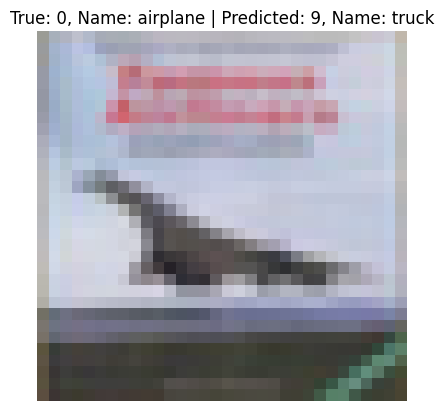

In [6]:
# --- Предсказание для одной картинки ---
import matplotlib.pyplot as plt

def predict_and_show(model, X_test, y_test, idx=0, class_names=None):
    """
    Прогоняет одну картинку из теста, показывает и пишет предсказание
    """
    x = X_test[idx:idx+1]  # сохранить форму [1, 3, 32, 32]
    y_true = y_test[idx]
    logits = model.forward(x)
    probs = np.exp(logits - np.max(logits)) / np.sum(np.exp(logits - np.max(logits)))
    y_pred = np.argmax(probs)

    # Визуализация
    img = np.transpose(x[0], (1, 2, 0))  # CHW → HWC
    plt.imshow(img)
    plt.axis('off')
    title = f"True: {y_true}"
    if class_names: title += f", Name: {class_names[y_true]}"
    title += f" | Predicted: {y_pred}"
    if class_names: title += f", Name: {class_names[y_pred]}"
    plt.title(title)
    plt.show()

# Пример использования:
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
predict_and_show(model, X_test, y_test, idx=3, class_names=cifar10_classes)
